<a href="https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pakizahassan/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# SETUP — CODE CELL

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import login

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Login
login(token=userdata.get("HF_TOKEN"))

# Only load columns needed for this task
columns = [
    "client_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

df = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_daily_performance/month=2026-03/data_0.parquet",
    columns=columns
)

df = df[df["client_hash_id"].notna()].reset_index(drop=True)

print("Rows:", len(df))
print("Clients:", df["client_hash_id"].nunique())

Rows: 9841378
Clients: 55


## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*



### Finding 1 — The Content Performance Curve

The FlyRank research paper reports that content reaches its strongest health level around 61–90 days and declines substantially around the 271–365 day range. Older content may also recover when it has been refreshed.

**My methodology question:**  
Are pages in the different age groups comparable in terms of client, topic, search demand, historical visibility, and content quality? Since this is an observational comparison, some of the observed difference may be explained by these other factors. Following the same pages over time could provide stronger evidence about how performance changes with age.

### Finding 2 — The Freshness Multiplier

The paper reports that the 31–90 day freshness window is the strongest stable freshness band and that recently refreshed older content shows substantially stronger performance than older comparison pages.

**My methodology question:**  
Were the refreshed and unrefreshed pages similar before the refresh occurred? Stronger or strategically important pages may be more likely to receive updates, which could introduce selection bias. A matched or before-and-after comparison could provide stronger evidence about the effect associated with refreshing.

In [2]:
paper_findings = pd.DataFrame({
    "Finding": [
        "Content Performance Curve",
        "Freshness Multiplier"
    ],
    "Evidence": [
        "Peak around 61-90 days; decline around 271-365 days",
        "31-90 days is the strongest stable freshness window"
    ]
})

display(paper_findings)


,Finding,Evidence
0,Content Performance Curve,Peak around 61-90 days; decline around 271-365...
1,Freshness Multiplier,31-90 days is the strongest stable freshness w...


## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

### Honest validation split

I first reproduced the Week 5 model using a random train-test split. I then evaluated the same model using a client-grouped split.

The grouped split prevents observations from the same client from appearing in both training and evaluation data. This provides a more realistic test of performance on unseen client groups.

In [3]:
# Target
df["needs_refresh"] = (
    (df["gsc_avg_position"] > 20) &
    (df["gsc_clicks"] < 5)
).astype("int8")

features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

X = (
    df[features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype("float32")
    .to_numpy()
)

y = df["needs_refresh"].to_numpy()
groups = df["client_hash_id"].astype("category").cat.codes.to_numpy()

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }


# Week 5 random split


indices = np.arange(len(y))

r_train, r_test = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X[r_train], y[r_train])

random_pred = model.predict(X[r_test])

random_metrics = get_metrics(
    y[r_test],
    random_pred
)


# Week 6 grouped split


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

g_train, g_test = next(
    gss.split(X, y, groups)
)

model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X[g_train], y[g_train])

grouped_pred = model.predict(X[g_test])

grouped_metrics = get_metrics(
    y[g_test],
    grouped_pred
)

comparison = pd.DataFrame([
    {"Validation": "Week 5 Random Split", **random_metrics},
    {"Validation": "Week 6 Grouped by Client", **grouped_metrics}
])

display(comparison.round(4))


,Validation,Accuracy,Precision,Recall,F1 Score
0,Week 5 Random Split,1.0,1.0,1.0,1.0
1,Week 6 Grouped by Client,1.0,1.0,1.0,1.0


The random and grouped evaluations both produced perfect measured performance. However, this result requires further investigation because the model may have access to variables that directly define the proxy target. I therefore performed a feature leakage audit before interpreting the performance as evidence of generalization.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*
### Leakage audit

The proxy target `needs_refresh` was created using `gsc_clicks` and `gsc_avg_position`.

Both variables were also included as Week 5 model features. This creates circularity because the Decision Tree can learn the rule used to construct the target rather than learn an independent real-world refresh outcome.

I therefore removed these two target-defining variables and re-evaluated the model using the same client-grouped split.

The cleaner evaluation does not make the proxy target a causal outcome, but it provides a more conservative test of the information contained in the remaining features.

In [4]:
leakage_audit = pd.DataFrame({
    "Feature": features,
    "Defines Target": [
        False,
        True,
        True,
        False,
        False,
        False
    ],
    "Risk": [
        "Low",
        "HIGH",
        "HIGH",
        "Low",
        "Low",
        "Low"
    ]
})

display(leakage_audit)

,Feature,Defines Target,Risk
0,gsc_impressions,False,Low
1,gsc_clicks,True,HIGH
2,gsc_avg_position,True,HIGH
3,ga4_sessions,False,Low
4,ga4_engaged_sessions,False,Low
5,scroll_events,False,Low


In [5]:
clean_features = [
    "gsc_impressions",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "scroll_events"
]

X_clean = (
    df[clean_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype("float32")
    .to_numpy()
)

clean_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

clean_model.fit(
    X_clean[g_train],
    y[g_train]
)

clean_pred = clean_model.predict(
    X_clean[g_test]
)

clean_metrics = get_metrics(
    y[g_test],
    clean_pred
)

display(
    pd.DataFrame(
        clean_metrics,
        index=["Grouped + Clean Features"]
    ).T.round(4)
)

,Grouped + Clean Features
Accuracy,0.9069
Precision,0.0000
Recall,0.0000
F1 Score,0.0000


In [6]:
baseline = max(
    np.mean(y[g_test] == 0),
    np.mean(y[g_test] == 1)
)

print("Majority baseline accuracy:", round(baseline, 4))
print("Clean model accuracy:", round(clean_metrics["Accuracy"], 4))

Majority baseline accuracy: 0.9072
Clean model accuracy: 0.9069


In [7]:
final_comparison = pd.DataFrame([
    {
        "Model": "Random + Original",
        **random_metrics
    },
    {
        "Model": "Grouped + Original",
        **grouped_metrics
    },
    {
        "Model": "Grouped + Clean",
        **clean_metrics
    }
])

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random + Original,1.0000,1.0,1.0,1.0
1,Grouped + Original,1.0000,1.0,1.0,1.0
2,Grouped + Clean,0.9069,0.0,0.0,0.0


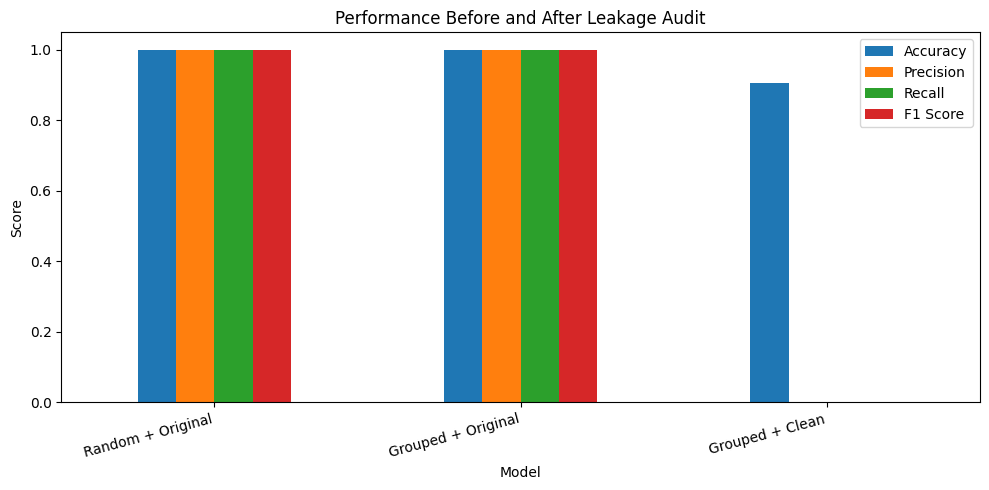

In [8]:
final_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Performance Before and After Leakage Audit")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

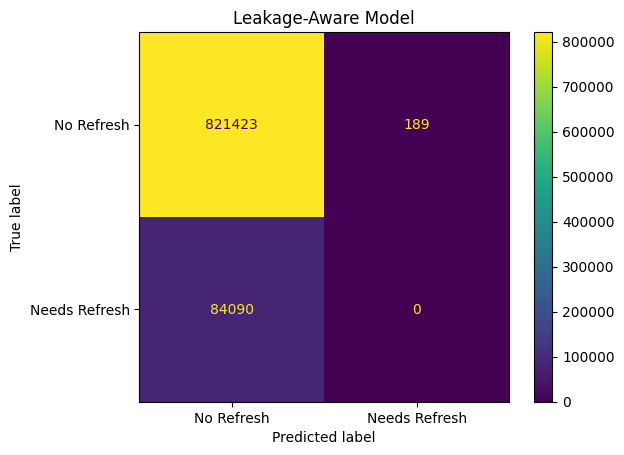

In [9]:
cm = confusion_matrix(
    y[g_test],
    clean_pred
)

ConfusionMatrixDisplay(
    cm,
    display_labels=[
        "No Refresh",
        "Needs Refresh"
    ]
).plot()

plt.title("Leakage-Aware Model")
plt.show()

In [10]:
test_results = df.iloc[g_test][
    clean_features
].copy()

test_results["actual"] = y[g_test]
test_results["predicted"] = clean_pred

false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
].head(5)

false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
].head(5)

print("False Positives")
display(false_positives)

print("False Negatives")
display(false_negatives)

False Positives


,gsc_impressions,ga4_sessions,ga4_engaged_sessions,scroll_events,actual,predicted
30155,2412,24.0,1.0,9.0,0,1
30786,1878,21.0,3.0,5.0,0,1
228880,12303,31.0,1.0,7.0,0,1
230903,3261,18.0,0.0,8.0,0,1
234851,2338,20.0,0.0,0.0,0,1


False Negatives


,gsc_impressions,ga4_sessions,ga4_engaged_sessions,scroll_events,actual,predicted
18862,5,0.0,0.0,0.0,1,0
18875,2,0.0,0.0,0.0,1,0
18891,3,0.0,0.0,0.0,1,0
18895,19,0.0,0.0,0.0,1,0
18909,10,0.0,0.0,0.0,1,0


### Interpretation

The original random and grouped models produced perfect measured performance, but the leakage audit showed that `gsc_clicks` and `gsc_avg_position` were directly involved in constructing the `needs_refresh` label.

After removing these target-defining variables, precision, recall, and F1 decreased substantially.

Accuracy remained relatively high because most observations belong to the `needs_refresh = 0` class. Therefore, accuracy alone gives an overly positive view of performance.

The low recall and F1 score indicate that the remaining features do not reliably identify the positive proxy class. This suggests that much of the original perfect performance was driven by circularity in the feature set.

The leakage-aware evaluation provides a more realistic view of the model's limitations.

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe

### Original claim

> The Decision Tree accurately identifies pages that need refreshing.

### Rewritten claim

The original Decision Tree produced perfect measured performance against the rule-derived refresh proxy, but the leakage audit showed that two target-defining variables were also included as model inputs.

After removing those variables and evaluating the model using a client-grouped split, precision, recall, and F1 decreased substantially.

The observed results therefore do not support a claim that the model reliably identifies pages that require refreshing. The leakage-aware model should instead be interpreted as an exploratory, directional decision-support signal rather than an automated refresh recommendation.

In [11]:
safe_words = [
    "observed",
    "measured",
    "directional",
    "decision-support"
]

print("Safe claim language used:")
for word in safe_words:
    print("✓", word)


Safe claim language used:
✓ observed
✓ measured
✓ directional
✓ decision-support


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.